# King County House Price Model

**Goal:** Build a hedonic pricing model to predict SFR sale prices in King County,  
quantifying the **marginal contribution** of each factor while controlling for all others.

**Why this matters over simple correlation:**  
- EDA showed school quality r = 0.77 with price — but top school districts also have bigger, newer homes  
- A model isolates: *holding house size and quality constant, how much is a better school district worth?*

**Sections**
1. Data loading & merging
2. Feature engineering
3. Predictor overview & rationale
4. Data quality & distributions
5. *(Modeling — next step)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

fmt_dol = mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
ENC      = 'latin-1'
DATA_DIR = Path('kc_assessor_data')
EDU_DIR  = Path('education_data')
CRIME_DIR = Path('crime_data')

---
## 1. Data Loading & Merging

**Datasets joined:**

| Dataset | Source | Joined on |
|---------|--------|-----------|
| Real Property Sales | KC Assessor | base table |
| Residential Building | KC Assessor | PIN |
| Parcel | KC Assessor | PIN |
| School district lookup | GIS spatial join | PIN |
| OSPI school quality | WA OSPI | district name |
| Crime scores | SPD / BallTree | PIN (Seattle only) |

**Sale filter (same as EDA):** `SaleReason=1` + `PropertyClass=8` + `SalePrice > $10K`  
**Time window:** 2015–2024 (10 years — enough volume, recent enough to reflect current market)  
**Property type:** Single-family residential only (`NbrLivingUnits=1`)

In [2]:
# ── Load KC Assessor ──────────────────────────────────────────────────────────
print('Loading KC Assessor data...')
rp  = pd.read_csv(DATA_DIR/'RealPropertySales/EXTR_RPSale.csv',   low_memory=False, encoding=ENC)
rb  = pd.read_csv(DATA_DIR/'ResidentialBuilding/EXTR_ResBldg.csv', low_memory=False, encoding=ENC)
par = pd.read_csv(DATA_DIR/'Parcel/EXTR_Parcel.csv',               low_memory=False, encoding=ENC)
lu  = pd.read_csv(DATA_DIR/'Lookup/EXTR_LookUp.csv',               low_memory=False, encoding=ENC)

def make_pin(df):
    return df['Major'].astype(str).str.zfill(6) + df['Minor'].astype(str).str.zfill(4)

for df in [rp, rb, par]:
    df['PIN'] = make_pin(df)

rp['DocumentDate'] = pd.to_datetime(rp['DocumentDate'], errors='coerce')
rp['SaleYear']  = rp['DocumentDate'].dt.year
rp['SaleMonth'] = rp['DocumentDate'].dt.month

print(f'  RPSale:  {len(rp):,} rows')
print(f'  ResBldg: {len(rb):,} rows')
print(f'  Parcel:  {len(par):,} rows')

Loading KC Assessor data...


  RPSale:  2,415,964 rows
  ResBldg: 532,072 rows
  Parcel:  627,512 rows


In [3]:
# ── Arms-length SFR sales filter ──────────────────────────────────────────────
al = rp[
    (rp['SaleReason']    == 1) &
    (rp['SalePrice']      > 10_000) &
    (rp['PropertyClass'] == 8) &
    (rp['SaleYear'].between(2015, 2024))
].copy()

rb_sfr = rb[
    (rb['NbrLivingUnits'] == 1) &
    (rb['SqFtTotLiving'].between(200, 15_000)) &
    (rb['YrBuilt'].between(1870, 2024))
].sort_values('BldgNbr').drop_duplicates('PIN', keep='first')

par_u = par.drop_duplicates('PIN', keep='first')

# Keep all sales (not just latest per PIN) — each sale is an observation
sales = (
    al
    .merge(rb_sfr[['PIN','SqFtTotLiving','SqFtFinBasement','BldgGrade','Condition',
                   'YrBuilt','YrRenovated','Bedrooms','BathFullCount',
                   'Bath3qtrCount','BathHalfCount','NbrLivingUnits',
                   'ViewUtilization','Stories']], on='PIN', how='inner')
    .merge(par_u[['PIN','SqFtLot','WfntLocation','WfntFootage',
                  'MtRainier','Olympics','Cascades','Territorial',
                  'SeattleSkyline','PugetSound','LakeWashington',
                  'LakeSammamish','SmallLakeRiverCreek','OtherView',
                  'TrafficNoise','PowerLines','OtherNuisances']], on='PIN', how='left')
)

print(f'Arms-length SFR sales 2015–2024: {len(sales):,}')
print(f'Unique properties (PIN):          {sales["PIN"].nunique():,}')
print(f'Sale year range: {sales["SaleYear"].min()} – {sales["SaleYear"].max()}')

Arms-length SFR sales 2015–2024: 261,482
Unique properties (PIN):          206,094
Sale year range: 2015 – 2024


In [4]:
# ── Merge school quality ───────────────────────────────────────────────────────
print('Merging school quality...')
ospi = pd.read_csv(EDU_DIR/'ospi_assessment_2324_king.csv', low_memory=False)
ospi_clean = ospi[ospi['dat'].isna() | (ospi['dat']=='None') | (ospi['dat']=='')].copy()
ospi_clean['pct_met'] = pd.to_numeric(
    ospi_clean['percent_consistent_grade_level_knowledge_and_above'].astype(str).str.rstrip('%'),
    errors='coerce')
school_scores = (
    ospi_clean
    .pivot_table(index='districtname', columns='testsubject', values='pct_met')
    .reset_index()
)
school_scores.columns.name = None
school_scores = school_scores.rename(columns={'Math':'pct_math','ELA':'pct_ela','Science':'pct_science'})
subj = [c for c in ['pct_math','pct_ela','pct_science'] if c in school_scores.columns]
school_scores['pct_composite'] = school_scores[subj].mean(axis=1)

def norm(name):
    if pd.isna(name): return name
    return re.sub(r'\s+School District.*', '', str(name), flags=re.IGNORECASE).strip().upper()

school_scores['_key'] = school_scores['districtname'].apply(norm)

pin_district = pd.read_csv(EDU_DIR/'kc_pin_district_lookup.csv')[['PIN','NAME']].drop_duplicates('PIN')
pin_district.columns = ['PIN','gis_name']
pin_district['_key'] = pin_district['gis_name'].apply(norm)

sales = (
    sales
    .merge(pin_district[['PIN','_key','gis_name']], on='PIN', how='left')
    .merge(school_scores[['_key','pct_composite','pct_math','pct_ela','pct_science']],
           on='_key', how='left')
)

match_rate = sales['pct_composite'].notna().mean()
print(f'School quality match rate: {match_rate:.1%}')
print(f'Districts matched: {sales["_key"].nunique()}')

Merging school quality...


School quality match rate: 99.5%
Districts matched: 20


In [5]:
# ── Merge crime scores (Seattle only) ─────────────────────────────────────────
print('Merging crime scores (Seattle only)...')
crime_scores = pd.read_csv(CRIME_DIR/'seattle_sales_crime_score.csv', dtype={'PIN': str})
sales = sales.merge(crime_scores, on='PIN', how='left')

n_crime = sales['crime_count_500m'].notna().sum()
print(f'Sales with crime score: {n_crime:,} ({n_crime/len(sales):.1%} of total)')
print('Note: crime score only available for Seattle bounding box properties')

Merging crime scores (Seattle only)...


Sales with crime score: 86,540 (32.9% of total)
Note: crime score only available for Seattle bounding box properties


---
## 2. Feature Engineering

Raw columns from the assessor data require several transformations before modeling.

In [6]:
# ── Feature engineering ───────────────────────────────────────────────────────

# Coerce all numeric-intended columns from string (KC Assessor CSVs load as object)
num_cols = (
    ['YrBuilt','YrRenovated','SqFtTotLiving','SqFtFinBasement','SqFtLot',
     'BldgGrade','Condition','Bedrooms','BathFullCount','Bath3qtrCount','BathHalfCount',
     'Stories','WfntLocation','WfntFootage','TrafficNoise','PowerLines','OtherNuisances'] +
    ['MtRainier','Olympics','Cascades','Territorial','SeattleSkyline',
     'PugetSound','LakeWashington','LakeSammamish','SmallLakeRiverCreek','OtherView']
)
for col in num_cols:
    if col in sales.columns:
        sales[col] = pd.to_numeric(sales[col], errors='coerce').fillna(0)

# --- Age ---
sales['EffectiveYear'] = np.where(sales['YrRenovated'] > 0, sales['YrRenovated'], sales['YrBuilt'])
sales['EffectiveAge']  = sales['SaleYear'] - sales['EffectiveYear']
sales['AgeAtSale']     = sales['SaleYear'] - sales['YrBuilt']
sales['IsRenovated']   = (sales['YrRenovated'] > 0).astype(int)

# --- Baths ---
sales['TotalBaths'] = (
    sales['BathFullCount'] + 0.75 * sales['Bath3qtrCount'] + 0.5 * sales['BathHalfCount']
)

# --- Waterfront & view ---
sales['IsWaterfront'] = (sales['WfntLocation'] > 0).astype(int)
view_cols = ['MtRainier','Olympics','Cascades','Territorial',
             'SeattleSkyline','PugetSound','LakeWashington',
             'LakeSammamish','SmallLakeRiverCreek','OtherView']
sales['ViewScore'] = sales[view_cols].sum(axis=1)
sales['HasView']   = (sales['ViewScore'] > 0).astype(int)

# --- Nuisances ---
sales['HasNuisance'] = (
    (sales['TrafficNoise'] > 0) | (sales['PowerLines'] > 0) | (sales['OtherNuisances'] > 0)
).astype(int)

# --- Lot & basement ---
sales['LogSqFtLot']    = np.log1p(sales['SqFtLot'].clip(lower=0))
sales['BasementRatio'] = (sales['SqFtFinBasement'] / sales['SqFtTotLiving'].replace(0, np.nan)).fillna(0)

# --- Target ---
sales['LogSalePrice'] = np.log(sales['SalePrice'])

print('Feature engineering complete.')
print(f'Total columns: {sales.shape[1]}')
print(f'Total rows:    {len(sales):,}')

Feature engineering complete.
Total columns: 76
Total rows:    262,747


---
## 3. Predictor Overview & Rationale

Features are grouped into four categories. Each includes the variable name, what it captures, and expected direction of effect on price.

---

### Category A — Structural Features
*What the building physically is. These are the strongest raw predictors.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `SqFtTotLiving` | Above-ground living area (sqft) | ↑ Strong positive — most important single predictor |
| `BldgGrade` | KC assessor quality grade (1–13; 7=Average) | ↑ Strong positive — captures finish quality, architecture |
| `Condition` | Physical condition (1–5; 3=Average) | ↑ Positive — well-maintained homes command premium |
| `Bedrooms` | Number of bedrooms | ↑ Positive, but may plateau; extra BRs past ~5 add less |
| `TotalBaths` | Weighted bath count (full=1, ¾=0.75, half=0.5) | ↑ Positive |
| `EffectiveAge` | Years since last renovation (or build if never renovated) | ↓ Negative — older effective age = lower price |
| `IsRenovated` | Binary: property has been renovated | ↑ Positive premium |
| `BasementRatio` | Finished basement / total living area | ↑ Slight positive — adds usable space |
| `Stories` | Number of floors | ↑ Mild positive |
| `LogSqFtLot` | Log of lot size | ↑ Positive — larger land = more value, log dampens outliers |

---

### Category B — Location & Amenity Features
*Where the property sits. Controls for natural amenity premium.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `IsWaterfront` | Binary: waterfront parcel | ↑ Very strong positive (~+150% from EDA) |
| `WfntFootage` | Feet of waterfront frontage | ↑ Positive, continuous |
| `ViewScore` | Composite view score (sum of 10 view columns, 0–40) | ↑ Positive — more view types = higher premium |
| `HasNuisance` | Binary: traffic noise / power lines / other nuisance | ↓ Negative |

---

### Category C — Neighborhood Quality Features
*The key factors this model is designed to isolate.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `pct_composite` | OSPI district composite pass rate (Math + ELA + Science avg) | ↑ Positive — school quality premium, controlling for structure |
| `crime_count_500m` | Serious crimes within 500m in 12 months before sale (Seattle only) | ↓ Negative — crime discount; weak in raw corr (r=−0.1) but may strengthen in model |

> **Note on crime feature scope:** `crime_count_500m` is only available for ~8% of sales (Seattle bounding box). Two modeling strategies to handle this:  
> (a) **Full KC model** — omit crime, use school quality + all structural/location features  
> (b) **Seattle-only model** — smaller dataset but includes crime score alongside school quality

---

### Category D — Temporal Features
*Controls for market cycle effects — a house sold in 2022 (peak) is worth more than the same house sold in 2015.*

| Feature | Description | Expected effect |
|---------|-------------|----------------|
| `SaleYear` | Year of sale (2015–2024) | Non-linear: captures market run-up and correction |
| `SaleMonth` | Month of sale (1–12) | Mild seasonal effect — spring/summer tend to be higher |

---

### Features Deliberately Excluded

| Feature | Reason for exclusion |
|---------|----------------------|
| `SalePrice` raw | Target variable (use `LogSalePrice`) |
| `PIN`, `Major`, `Minor` | ID fields, no predictive signal |
| `YrBuilt` | Collinear with `EffectiveAge` — use engineered version |
| `YrRenovated` | Encoded into `EffectiveAge` and `IsRenovated` |
| `BathFullCount`, `Bath3qtrCount`, `BathHalfCount` | Rolled into `TotalBaths` |
| `SqFtLot` raw | Use `LogSqFtLot` — raw is heavily right-skewed |
| Individual view columns (10) | Rolled into `ViewScore` — reduces dimensionality |
| `pct_math`, `pct_ela`, `pct_science` | Collinear with `pct_composite` — use composite |
| `gis_name` / `_key` (district name) | High-cardinality string; school quality is captured numerically via `pct_composite` |

---
## 4. Data Quality & Distributions

Check missingness, target distribution, and any obvious data issues before modeling.

In [7]:
# ── Define modeling feature set ───────────────────────────────────────────────
FEATURES_STRUCTURAL = [
    'SqFtTotLiving', 'BldgGrade', 'Condition', 'Bedrooms', 'TotalBaths',
    'EffectiveAge', 'IsRenovated', 'BasementRatio', 'Stories', 'LogSqFtLot'
]
FEATURES_LOCATION = [
    'IsWaterfront', 'WfntFootage', 'ViewScore', 'HasNuisance'
]
FEATURES_NEIGHBORHOOD = [
    'pct_composite',      # school quality (KC-wide)
    'crime_count_500m',   # crime exposure (Seattle only)
]
FEATURES_TEMPORAL = [
    'SaleYear', 'SaleMonth'
]
ALL_FEATURES = FEATURES_STRUCTURAL + FEATURES_LOCATION + FEATURES_NEIGHBORHOOD + FEATURES_TEMPORAL
TARGET = 'LogSalePrice'

model_df = sales[ALL_FEATURES + [TARGET, 'SalePrice']].copy()

# Missingness report
missing = model_df[ALL_FEATURES].isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(model_df) * 100).round(1)
miss_report = pd.DataFrame({'missing_n': missing, 'missing_%': missing_pct})
print('=== Missingness Report ===')
print(miss_report[miss_report['missing_n'] > 0].to_string())
print(f'\nTotal rows: {len(model_df):,}')

=== Missingness Report ===
                  missing_n  missing_%
crime_count_500m     176207      67.10
pct_composite          1228       0.50

Total rows: 262,747


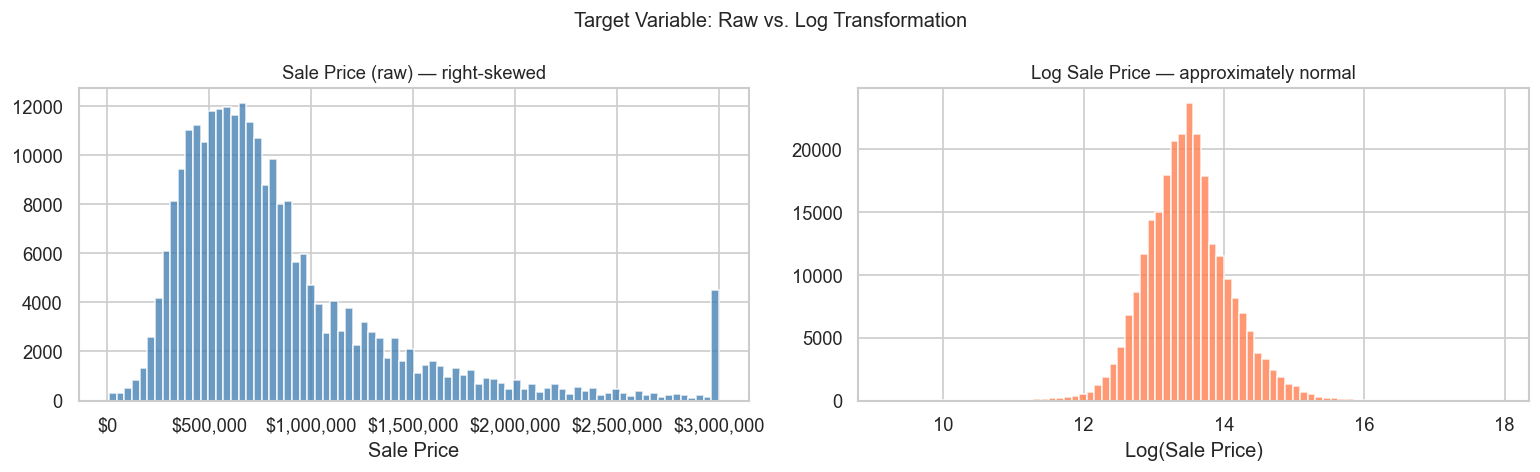

Sale price range: $10,091 – $60,000,000
Median: $700,000   Mean: $875,765


In [8]:
# ── Target variable distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(model_df['SalePrice'].clip(upper=3_000_000), bins=80,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].xaxis.set_major_formatter(fmt_dol)
axes[0].set_title('Sale Price (raw) — right-skewed', fontsize=11)
axes[0].set_xlabel('Sale Price')

axes[1].hist(model_df[TARGET], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Log Sale Price — approximately normal', fontsize=11)
axes[1].set_xlabel('Log(Sale Price)')

plt.suptitle('Target Variable: Raw vs. Log Transformation', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Sale price range: ${model_df["SalePrice"].min():,.0f} – ${model_df["SalePrice"].max():,.0f}')
print(f'Median: ${model_df["SalePrice"].median():,.0f}   Mean: ${model_df["SalePrice"].mean():,.0f}')

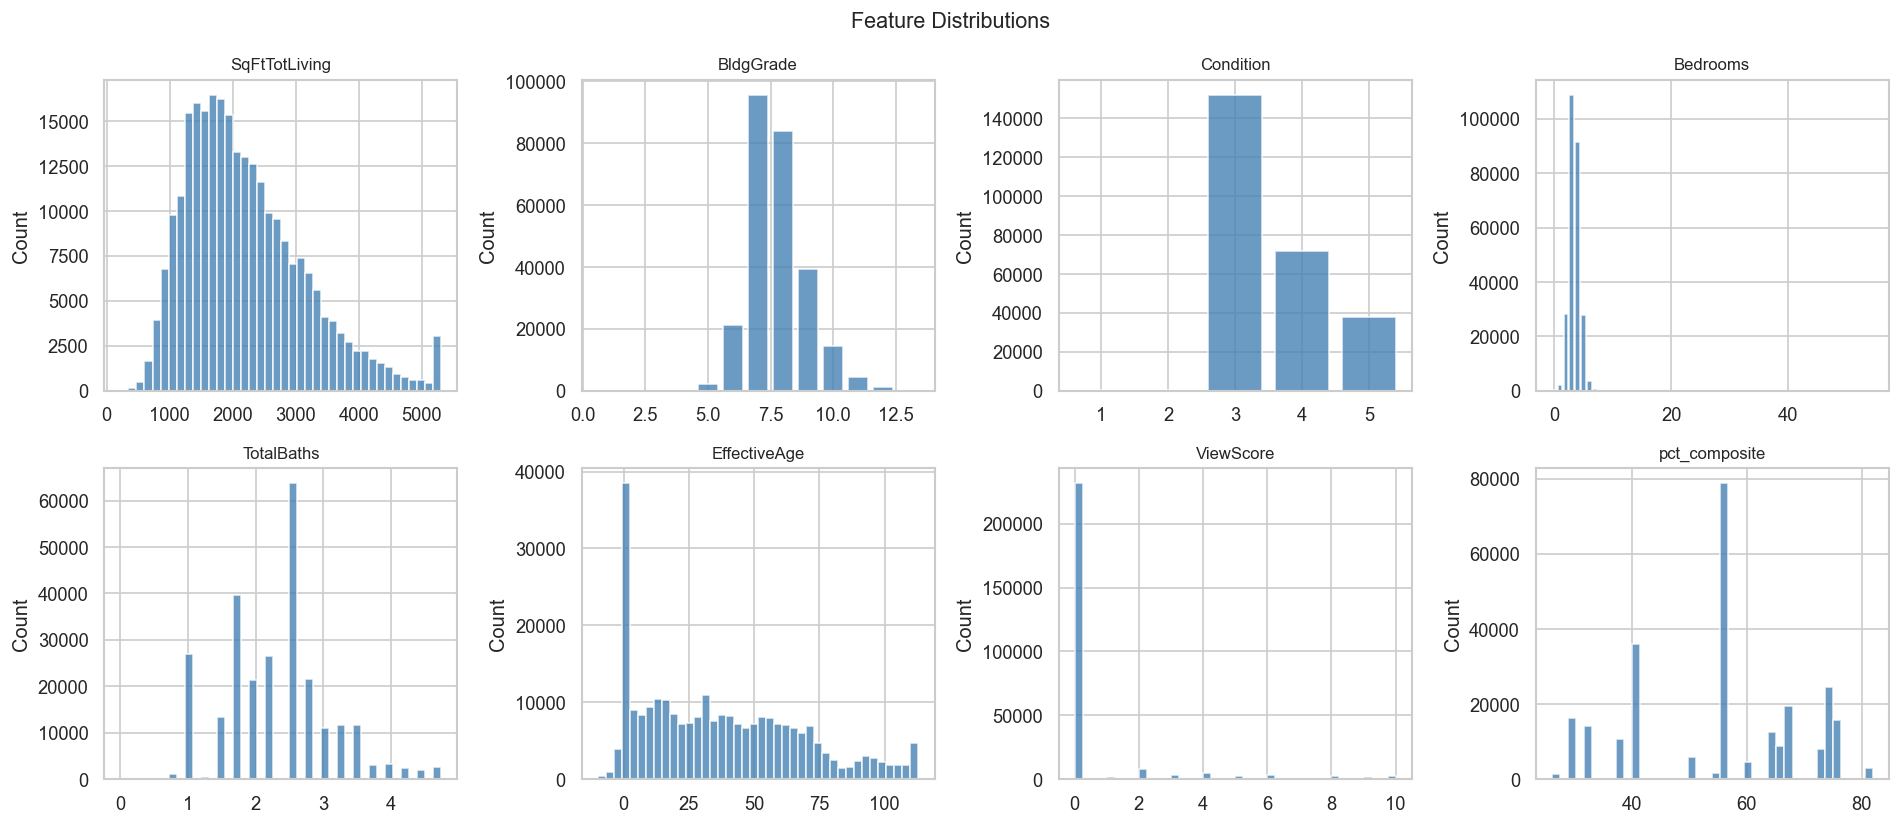

In [9]:
# ── Feature distributions overview ───────────────────────────────────────────
plot_features = ['SqFtTotLiving','BldgGrade','Condition','Bedrooms',
                 'TotalBaths','EffectiveAge','ViewScore','pct_composite']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), plot_features):
    data = model_df[col].dropna()
    if col in ['BldgGrade','Condition','Bedrooms']:
        vc = data.astype(int).value_counts().sort_index()
        ax.bar(vc.index, vc.values, color='steelblue', alpha=0.8)
    else:
        ax.hist(data.clip(upper=data.quantile(0.99)), bins=40,
                color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

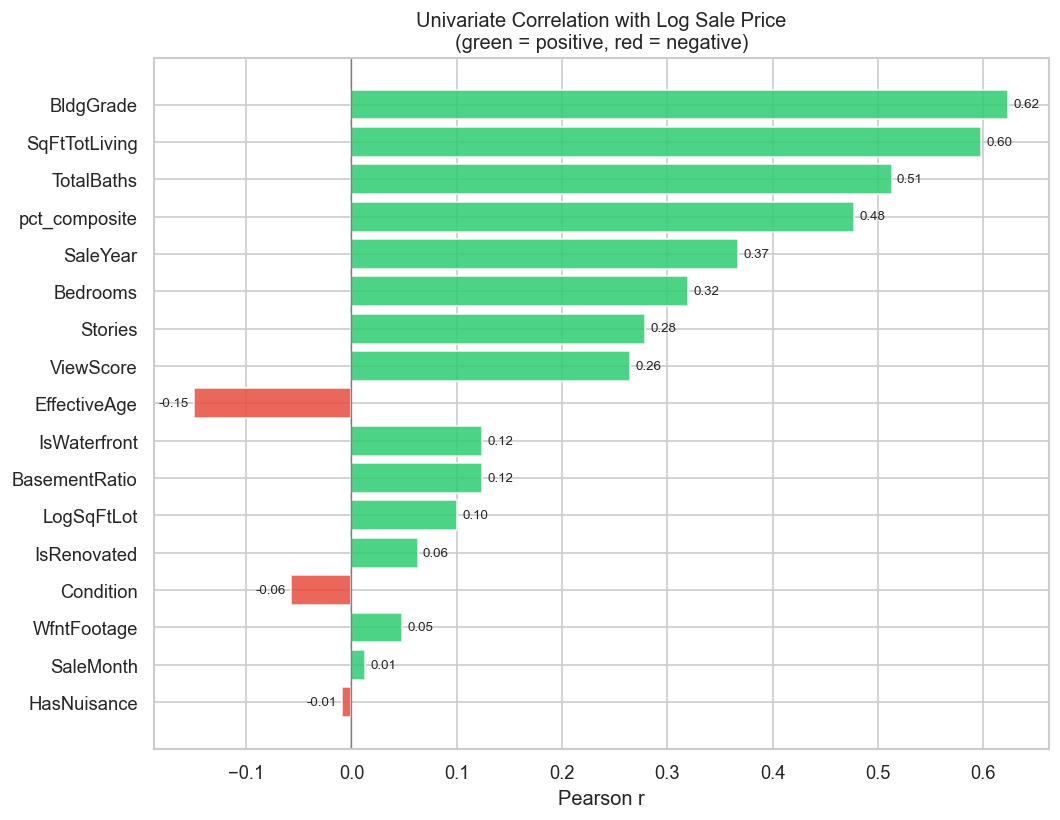

In [10]:
# ── Correlation with log price (univariate signal strength) ───────────────────
corr_features = [f for f in ALL_FEATURES if f != 'crime_count_500m']  # exclude sparse feature
corr = (
    model_df[corr_features + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='gray', lw=0.8)
for i, (feat, val) in enumerate(corr.items()):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_title('Univariate Correlation with Log Sale Price\n(green = positive, red = negative)',
             fontsize=12)
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

---
## 5. Modeling — Next Steps

| Step | Plan |
|------|------|
| Train/test split | 80/20, stratified by `SaleYear` to avoid temporal leakage |
| Baseline | Linear regression (OLS) — interpretable coefficients, validates sign of each feature |
| Main model | XGBoost or Random Forest — captures non-linear interactions (e.g. BldgGrade × SqFt) |
| Evaluation | RMSE and MAE on raw price (back-transform exp); R² on log price |
| Interpretability | SHAP values — show marginal contribution of each feature per prediction |
| Two model variants | (a) Full KC — all features except crime; (b) Seattle-only — includes crime score |

> **Open question before modeling:** Handle `crime_count_500m` missingness —  
> options: (a) impute with district median, (b) use 0 as default (no nearby crime data = suburban = low crime), (c) separate models